In [1]:
import numpy as np
import pandas as pd
from neuralprophet import NeuralProphet
from matplotlib import pyplot as plt
import pickle

C:\Users\Vahid\Anaconda3\lib\site-packages\setuptools\_importlib.py:23: UserWarning: `importlib-metadata` version is incompatible with `setuptools`.
This problem is likely to be solved by installing an updated version of `importlib-metadata`.
  warnings.warn(msg)  # Ensure a descriptive message is shown.
C:\Users\Vahid\Anaconda3\lib\site-packages\pandas\compat\_optional.py:138: UserWarning: Pandas requires version '2.7.0' or newer of 'numexpr' (version '2.6.9' currently installed).
  warnings.warn(msg, UserWarning)


In [2]:
df=pd.read_csv('D:\\paper\\C\\Weatherdata\\Hourlyc.csv')
df.head()

,date,دید افقی,cloudy,wind direction,wind speed,temp,dew point,QFE,QFF,حداكثر دما,...,ارتفاع برف,سريعترين باد)سمت(,سريعترين باد)سرعت(,دمای اعماق خاک(5cm),دمای اعماق خاک(10cm),دمای اعماق خاک(20cm),دمای اعماق خاک(30),دمای اعماق خاک(50cm),دمای اعماق خاک100cm),Unnamed: 24
0,1/1/2013,20,0,80,6,-2.4,-6.6,914.3,1032.4,1.4,...,NaN,NaN,NaN,0.0,1.0,3.0,4.4,7.2,12.6,NaN
1,1/2/2013,15,0,80,3,-0.6,-9.5,912.7,1030.4,4.2,...,NaN,NaN,NaN,-0.2,0.8,2.6,4.2,7.0,12.2,NaN
2,1/3/2013,20,1,60,4,-1.0,-6.9,915.3,1033.2,5.2,...,NaN,NaN,NaN,0.2,1.4,2.8,4.2,6.8,12.2,NaN
3,1/4/2013,15,0,70,4,-0.6,-7.0,910.7,1028.0,3.2,...,NaN,NaN,NaN,0.4,1.4,2.8,4.0,6.6,11.6,NaN
4,1/5/2013,15,3,60,4,1.8,-5.6,902.1,1017.3,6.4,...,NaN,NaN,NaN,2.0,2.6,3.2,4.2,6.4,11.6,NaN


In [3]:
#df.hour.unique()

In [4]:
df.columns

Index(['date', 'دید افقی', 'cloudy', 'wind direction', 'wind speed', 'temp',
       'dew point', 'QFE', 'QFF', 'حداكثر دما', 'حداقل دما دماي سطح زمين',
       'حداقل دماي سطح زمين', 'ساعات آفتابي', 'بارندگي', 'rel_humid',
       'ارتفاع برف', 'سريعترين باد)سمت(', 'سريعترين باد)سرعت(',
       'دمای اعماق خاک(5cm)', 'دمای اعماق خاک(10cm)', 'دمای اعماق خاک(20cm)',
       'دمای اعماق خاک(30)', 'دمای اعماق خاک(50cm)', 'دمای اعماق خاک100cm)',
       'Unnamed: 24'],
      dtype='object')

In [5]:
df.dtypes

date                        object
دید افقی                     int64
cloudy                       int64
wind direction               int64
wind speed                   int64
temp                       float64
dew point                  float64
QFE                        float64
QFF                        float64
حداكثر دما                 float64
حداقل دما دماي سطح زمين    float64
حداقل دماي سطح زمين        float64
ساعات آفتابي               float64
بارندگي                    float64
rel_humid                  float64
ارتفاع برف                 float64
سريعترين باد)سمت(          float64
سريعترين باد)سرعت(         float64
دمای اعماق خاک(5cm)        float64
دمای اعماق خاک(10cm)       float64
دمای اعماق خاک(20cm)       float64
دمای اعماق خاک(30)         float64
دمای اعماق خاک(50cm)       float64
دمای اعماق خاک100cm)        object
Unnamed: 24                float64
dtype: object

In [6]:
df["date"] = pd.to_datetime(df["date"])
df.head()

,date,دید افقی,cloudy,wind direction,wind speed,temp,dew point,QFE,QFF,حداكثر دما,...,ارتفاع برف,سريعترين باد)سمت(,سريعترين باد)سرعت(,دمای اعماق خاک(5cm),دمای اعماق خاک(10cm),دمای اعماق خاک(20cm),دمای اعماق خاک(30),دمای اعماق خاک(50cm),دمای اعماق خاک100cm),Unnamed: 24
0,2013-01-01,20,0,80,6,-2.4,-6.6,914.3,1032.4,1.4,...,NaN,NaN,NaN,0.0,1.0,3.0,4.4,7.2,12.6,NaN
1,2013-01-02,15,0,80,3,-0.6,-9.5,912.7,1030.4,4.2,...,NaN,NaN,NaN,-0.2,0.8,2.6,4.2,7.0,12.2,NaN
2,2013-01-03,20,1,60,4,-1.0,-6.9,915.3,1033.2,5.2,...,NaN,NaN,NaN,0.2,1.4,2.8,4.2,6.8,12.2,NaN
3,2013-01-04,15,0,70,4,-0.6,-7.0,910.7,1028.0,3.2,...,NaN,NaN,NaN,0.4,1.4,2.8,4.0,6.6,11.6,NaN
4,2013-01-05,15,3,60,4,1.8,-5.6,902.1,1017.3,6.4,...,NaN,NaN,NaN,2.0,2.6,3.2,4.2,6.4,11.6,NaN


In [7]:
df.dtypes

date                       datetime64[ns]
دید افقی                            int64
cloudy                              int64
wind direction                      int64
wind speed                          int64
temp                              float64
dew point                         float64
QFE                               float64
QFF                               float64
حداكثر دما                        float64
حداقل دما دماي سطح زمين           float64
حداقل دماي سطح زمين               float64
ساعات آفتابي                      float64
بارندگي                           float64
rel_humid                         float64
ارتفاع برف                        float64
سريعترين باد)سمت(                 float64
سريعترين باد)سرعت(                float64
دمای اعماق خاک(5cm)               float64
دمای اعماق خاک(10cm)              float64
دمای اعماق خاک(20cm)              float64
دمای اعماق خاک(30)                float64
دمای اعماق خاک(50cm)              float64
دمای اعماق خاک100cm)              

WARNING - (py.warnings._showwarnmsg) - C:\Users\Vahid\Anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1377: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]

WARNING - (py.warnings._showwarnmsg) - C:\Users\Vahid\Anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1377: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]

WARNING - (py.warnings._showwarnmsg) - C:\Users\Vahid\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:237: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]

WARNING - (py.warnings._showwarnmsg) - C:\Users\Vahid\An

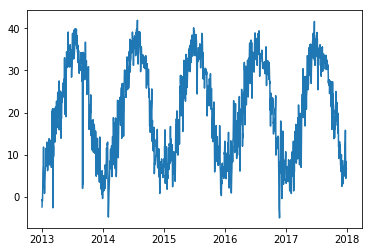

In [8]:
plt.plot(df["date"], df["temp"])
plt.show()

In [9]:
#df["Year"] = df["date"].apply(lambda x: x.year)
#df = df[df["Year"]<=2014]
#plt.plot(df["date"], df["temp15"])
#plt.show

In [10]:
#df.tail()

In [11]:
null_pct=df.apply(pd.isnull).sum()/df.shape[0]


In [12]:
null_pct

date                       0.000000
دید افقی                   0.000000
cloudy                     0.000000
wind direction             0.000000
wind speed                 0.000000
temp                       0.000000
dew point                  0.000000
QFE                        0.000000
QFF                        0.000000
حداكثر دما                 0.001096
حداقل دما دماي سطح زمين    0.998904
حداقل دماي سطح زمين        1.000000
ساعات آفتابي               1.000000
بارندگي                    1.000000
rel_humid                  0.001096
ارتفاع برف                 0.998904
سريعترين باد)سمت(          1.000000
سريعترين باد)سرعت(         1.000000
دمای اعماق خاک(5cm)        0.002192
دمای اعماق خاک(10cm)       0.001096
دمای اعماق خاک(20cm)       0.001096
دمای اعماق خاک(30)         0.001096
دمای اعماق خاک(50cm)       0.001096
دمای اعماق خاک100cm)       0.001096
Unnamed: 24                0.998904
dtype: float64

In [13]:
valid_columns=df.columns[null_pct<0.05]

In [14]:
valid_columns

Index(['date', 'دید افقی', 'cloudy', 'wind direction', 'wind speed', 'temp',
       'dew point', 'QFE', 'QFF', 'حداكثر دما', 'rel_humid',
       'دمای اعماق خاک(5cm)', 'دمای اعماق خاک(10cm)', 'دمای اعماق خاک(20cm)',
       'دمای اعماق خاک(30)', 'دمای اعماق خاک(50cm)', 'دمای اعماق خاک100cm)'],
      dtype='object')

In [15]:
df=df[valid_columns].copy()

In [16]:
df

,date,دید افقی,cloudy,wind direction,wind speed,temp,dew point,QFE,QFF,حداكثر دما,rel_humid,دمای اعماق خاک(5cm),دمای اعماق خاک(10cm),دمای اعماق خاک(20cm),دمای اعماق خاک(30),دمای اعماق خاک(50cm),دمای اعماق خاک100cm)
0,2013-01-01,20,0,80,6,-2.4,-6.6,914.3,1032.4,1.4,73.0,0.0,1.0,3.0,4.4,7.2,12.6
1,2013-01-02,15,0,80,3,-0.6,-9.5,912.7,1030.4,4.2,51.0,-0.2,0.8,2.6,4.2,7.0,12.2
2,2013-01-03,20,1,60,4,-1.0,-6.9,915.3,1033.2,5.2,64.0,0.2,1.4,2.8,4.2,6.8,12.2
3,2013-01-04,15,0,70,4,-0.6,-7.0,910.7,1028.0,3.2,62.0,0.4,1.4,2.8,4.0,6.6,11.6
4,2013-01-05,15,3,60,4,1.8,-5.6,902.1,1017.3,6.4,58.0,2.0,2.6,3.2,4.2,6.4,11.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1820,2017-12-27,20,0,50,2,7.4,-10.2,918.3,1033.3,12.6,26.0,7.8,8.2,9.4,12.4,13.0,15.8
1821,2017-12-28,20,0,350,2,4.4,-8.6,915.4,1030.8,14.6,38.0,8.4,9.6,9.8,10.8,12.6,16
1822,2017-12-29,20,6,20,2,8.4,-8.8,912.6,1027.0,13.0,28.0,9.0,9.2,9.0,10.2,12.2,15.8
1823,2017-12-30,20,5,0,0,6.9,-6.2,911.0,1025.5,14.7,39.0,9.2,9.6,9.2,10.2,12.2,15.8


In [17]:
data = df[["date", "temp"]]
data.dropna(inplace=True)
data.columns = ["ds", "y"]
data.head()

WARNING - (py.warnings._showwarnmsg) - C:\Users\Vahid\Anaconda3\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)



,ds,y
0,2013-01-01,-2.4
1,2013-01-02,-0.6
2,2013-01-03,-1.0
3,2013-01-04,-0.6
4,2013-01-05,1.8


In [18]:
#data = df[["date", "temp15"]]
#data.rename(columns={"date": "ds", "temp15": "y"}, inplace=True)

In [19]:
data

,ds,y
0,2013-01-01,-2.4
1,2013-01-02,-0.6
2,2013-01-03,-1.0
3,2013-01-04,-0.6
4,2013-01-05,1.8
...,...,...
1820,2017-12-27,7.4
1821,2017-12-28,4.4
1822,2017-12-29,8.4
1823,2017-12-30,6.9


In [20]:
#train model
m = NeuralProphet()
m.fit(data, freq="D")

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.89% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 162


  0%|          | 0/132 [00:00<?, ?it/s]

INFO - (NP.utils_torch.lr_range_test) - lr-range-test results: steep: 6.91E-02, min: 1.02E+00


  0%|          | 0/132 [00:00<?, ?it/s]

INFO - (NP.utils_torch.lr_range_test) - lr-range-test results: steep: 8.10E-02, min: 8.69E-01
INFO - (NP.forecaster._init_train_loader) - lr-range-test selected learning rate: 8.24E-02
Epoch[162/162]: 100%|██████████| 162/162 [00:15<00:00, 10.17it/s, SmoothL1Loss=0.00373, MAE=2.69, RMSE=3.53, Loss=0.00273, RegLoss=0]


,SmoothL1Loss,MAE,RMSE,Loss,RegLoss
0,0.575740,40.002198,51.792623,0.439793,0.0
1,0.490362,35.826982,47.086585,0.373105,0.0
2,0.397082,31.065423,41.268665,0.300772,0.0
3,0.294992,25.513615,34.457672,0.222349,0.0
4,0.191578,19.258341,26.554291,0.143790,0.0
...,...,...,...,...,...
157,0.003747,2.700288,3.539463,0.002744,0.0
158,0.003740,2.697919,3.521571,0.002737,0.0
159,0.003732,2.694053,3.541442,0.002731,0.0
160,0.003729,2.692238,3.541153,0.002729,0.0


In [21]:
#forcasting
future = m.make_future_dataframe(data, periods=1825)
forecast = m.predict(future)
forecast

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.89% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.945% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.945% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


,ds,y,residual1,yhat1,trend,season_yearly,season_weekly
0,2018-01-01,None,None,7.109665,21.554310,-14.427532,-0.017111
1,2018-01-02,None,None,7.228833,21.556665,-14.404202,0.076370
2,2018-01-03,None,None,7.288835,21.559025,-14.379867,0.109678
3,2018-01-04,None,None,7.276242,21.561382,-14.354685,0.069543
4,2018-01-05,None,None,7.234243,21.563742,-14.328776,-0.000722
...,...,...,...,...,...,...,...
1820,2022-12-26,None,None,11.292526,25.846460,-14.536823,-0.017111
1821,2022-12-27,None,None,11.400141,25.848820,-14.525047,0.076370
1822,2022-12-28,None,None,11.450188,25.851179,-14.510668,0.109678
1823,2022-12-29,None,None,11.429073,25.853537,-14.494006,0.069543


In [22]:
forecast.tail()

,ds,y,residual1,yhat1,trend,season_yearly,season_weekly
1820,2022-12-26,None,NaN,11.292526,25.846460,-14.536823,-0.017111
1821,2022-12-27,None,NaN,11.400141,25.848820,-14.525047,0.076370
1822,2022-12-28,None,NaN,11.450188,25.851179,-14.510668,0.109678
1823,2022-12-29,None,NaN,11.429073,25.853537,-14.494006,0.069543
1824,2022-12-30,None,NaN,11.379816,25.855894,-14.475356,-0.000722


WARNING - (py.warnings._showwarnmsg) - C:\Users\Vahid\Anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1377: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]

WARNING - (py.warnings._showwarnmsg) - C:\Users\Vahid\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:239: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]



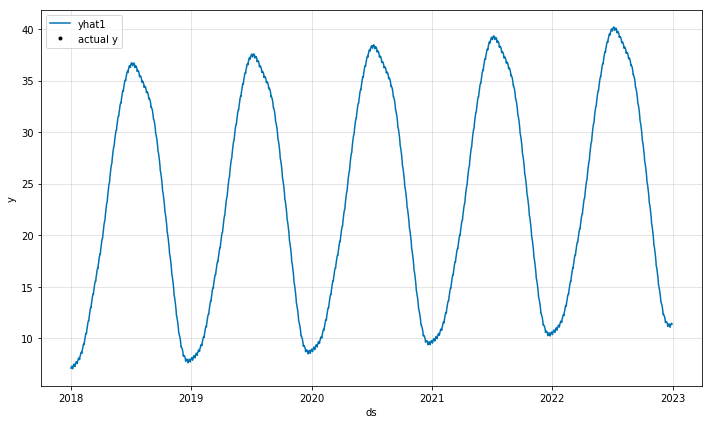

In [23]:
plot1 = m.plot(forecast)

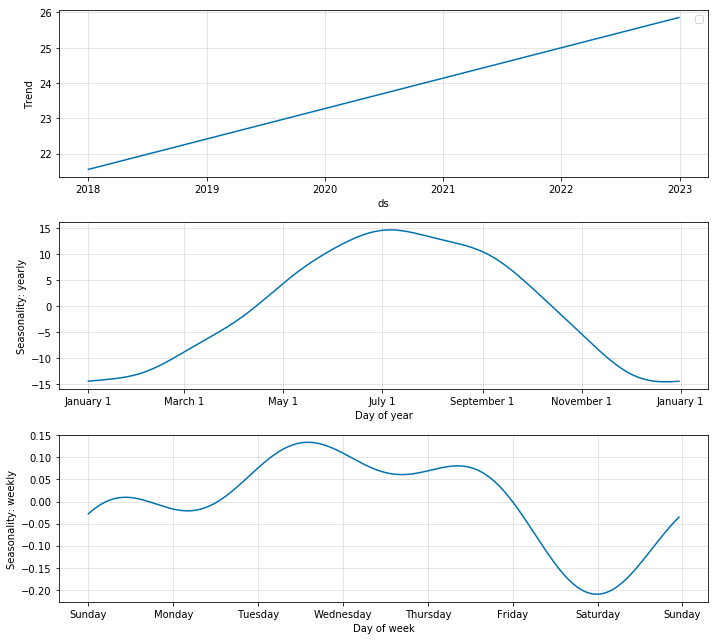

In [24]:
plot2 = m.plot_components(forecast)

In [25]:
#save model

with open("forecast_model.pk1", "wb") as f:
    pickle.dump(m, f)

In [26]:
m

In [27]:
del m

In [28]:
with open("forecast_model.pk1", "rb") as f:
      m = pickle.load(f)

In [29]:
m

In [30]:
#forcasting
future = m.make_future_dataframe(data, periods=900)
forecast = m.predict(future)
forecast

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.89% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.889% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.889% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


,ds,y,residual1,yhat1,trend,season_yearly,season_weekly
0,2018-01-01,None,None,7.109665,21.554310,-14.427532,-0.017111
1,2018-01-02,None,None,7.228833,21.556665,-14.404202,0.076370
2,2018-01-03,None,None,7.288835,21.559025,-14.379867,0.109678
3,2018-01-04,None,None,7.276242,21.561382,-14.354685,0.069543
4,2018-01-05,None,None,7.234243,21.563742,-14.328776,-0.000722
...,...,...,...,...,...,...,...
895,2020-06-14,None,None,36.704193,23.665010,13.067039,-0.027856
896,2020-06-15,None,None,36.849163,23.667368,13.198904,-0.017111
897,2020-06-16,None,None,37.072460,23.669727,13.326364,0.076370
898,2020-06-17,None,None,37.230946,23.672083,13.449183,0.109678


WARNING - (py.warnings._showwarnmsg) - C:\Users\Vahid\Anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1377: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]

WARNING - (py.warnings._showwarnmsg) - C:\Users\Vahid\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:239: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]



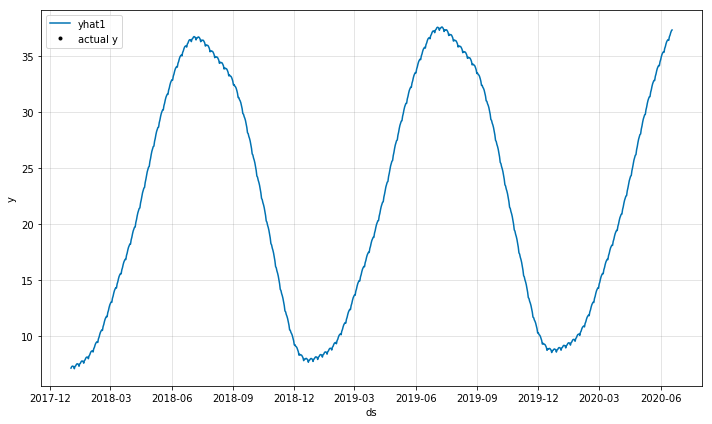

In [31]:
plot1 = m.plot(forecast)